SAR (Synthetic Aperture Radar) Data is a radar-based imaging technique that captures high-resolution Earth images, working in all weather conditions, day and night.

Uses in Flood Prediction:

1.Water Detection – Differentiates land and water using backscatter intensity.

2.Pre/Post-Flood Analysis – Identifies inundated areas by comparing images.

3.DEM (Digital Elevation Model)  Integration – Helps understand water flow and flood-prone zones.

4.Critical Zone Identification – Highlights vulnerable areas for better planning.

Extracting the zip files

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 21.1 MB/s eta 0:00:00


**SAR VV and SAR VH refer to the two main polarization modes in Synthetic Aperture Radar (SAR) data, particularly from Sentinel-1.**

**SAR VV (Vertical-Vertical):**

Transmits and receives signals in the vertical polarization.

More sensitive to surface roughness and open water bodies.

Useful for detecting water bodies, urban structures, and rough surfaces.

Often shows higher backscatter over dry areas and less over flooded areas.

**SAR VH (Vertical-Horizontal):**

Transmits in vertical and receives in horizontal polarization.

More sensitive to volume scattering (e.g., vegetation or flooded areas).

Better at detecting water beneath vegetation and capturing changes in land cover.

Typically shows lower backscatter in flooded areas compared to dry conditions.

Together, VV and VH polarization data are used for flood mapping, vegetation monitoring, and disaster management.

The code processes Synthetic Aperture Radar (SAR) images for flood detection by loading pre-flood and post-flood SAR data, specifically VV (Vertical-Vertical) and VH (Vertical-Horizontal) polarized bands. It resamples the images for efficiency, normalizes the pixel values for better visualization, and converts them from decibel (dB) scale to a linear scale to enhance interpretability. The images are then visualized to compare pre-flood and post-flood conditions, where darker regions in post-flood images indicate water accumulation. This analysis helps in identifying flood-affected areas by detecting changes in SAR backscatter intensity before and after the flood event.

Pre-Flood VV Min: 0.0 Max: 24491.0
Post-Flood VV Min: 0.0 Max: 21049.0


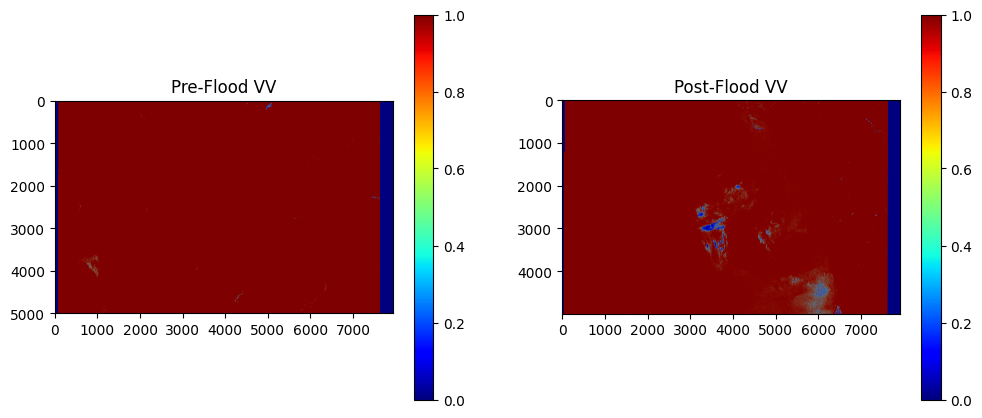

In [ ]:
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt

# Load SAR images with resampling to reduce size
def load_raster(file_path, scale_factor=0.3):
    with rasterio.open(file_path) as src:
        # Reduce resolution to save memory
        new_width = int(src.width * scale_factor)
        new_height = int(src.height * scale_factor)

        image = src.read(
            1,
            out_shape=(new_height, new_width),
            resampling=Resampling.bilinear
        ).astype(np.float32)  # Ensure float type for normalization

        profile = src.profile
    return image, profile

# Normalize function to scale data for better visualization
def normalize(array):
     array = array - np.min(array)  # Shift values to be non-negative
     if np.max(array) > 0:
        return array / np.max(array)  # Normalize safely
     else:
       return array  # Avoid division by zero
 # Avoid division by zero

# Convert from dB scale to linear scale if needed
def convert_to_linear(array):
  return 10 ** (np.clip(array, -50, 50) / 10)  # Clip extreme values to avoid overflow
 # Converts dB values to linear scale

# File paths (update if needed)
pre_flood_vv_path = "/content/drive/MyDrive/SAR/PRE FLOOD/S1A_IW_GRDH_1SDV_20240919T061016_20240919T061041_055730_06CE99_48B3.SAFE/measurement/s1a-iw-grd-vv-20240919t061016-20240919t061041-055730-06ce99-001.tiff"
post_flood_vv_path = "/content/drive/MyDrive/SAR/POST FLOOD/S1A_IW_GRDH_1SDV_20241101T060207_20241101T060232_056357_06E766_FEB3.SAFE/measurement/s1a-iw-grd-vv-20241101t060207-20241101t060232-056357-06e766-001.tiff"

pre_flood_vh_path = "/content/drive/MyDrive/SAR/PRE FLOOD/S1A_IW_GRDH_1SDV_20240919T061016_20240919T061041_055730_06CE99_48B3.SAFE/measurement/s1a-iw-grd-vh-20240919t061016-20240919t061041-055730-06ce99-002.tiff"
post_flood_vh_path = "/content/drive/MyDrive/SAR/POST FLOOD/S1A_IW_GRDH_1SDV_20241101T060207_20241101T060232_056357_06E766_FEB3.SAFE/measurement/s1a-iw-grd-vh-20241101t060207-20241101t060232-056357-06e766-002.tiff"

# Load SAR images (Resampled)
pre_flood_vv, profile = load_raster(pre_flood_vv_path, scale_factor=0.3)
post_flood_vv, _ = load_raster(post_flood_vv_path, scale_factor=0.3)
pre_flood_vh, _ = load_raster(pre_flood_vh_path, scale_factor=0.3)
post_flood_vh, _ = load_raster(post_flood_vh_path, scale_factor=0.3)

# Print Min-Max values to check variations
print("Pre-Flood VV Min:", np.min(pre_flood_vv), "Max:", np.max(pre_flood_vv))
print("Post-Flood VV Min:", np.min(post_flood_vv), "Max:", np.max(post_flood_vv))

# Convert from dB to Linear Scale if needed
pre_flood_vv = convert_to_linear(pre_flood_vv)
post_flood_vv = convert_to_linear(post_flood_vv)

# Normalize images for better visualization
pre_flood_vv_norm = normalize(pre_flood_vv)
post_flood_vv_norm = normalize(post_flood_vv)

# Plot the SAR VV before and after the flood
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = axes[0].imshow(pre_flood_vv_norm, cmap='jet')
axes[0].set_title("Pre-Flood VV")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(post_flood_vv_norm, cmap='jet')
axes[1].set_title("Post-Flood VV")
plt.colorbar(im2, ax=axes[1])

plt.show()


**Interpretation from the Image**

**Flooded Areas Identification**

1.In the Pre-Flood VV Image, most areas appear dark red, meaning they had relatively low water presence or dry land.

2.In the Post-Flood VV Image, some regions turn blue/cyan, indicating a significant change in backscatter values, which is characteristic of water bodies.

3.This change suggests newly inundated areas, confirming flood occurrence.

**Changes in Backscatter Intensity**

1.The decrease in VV backscatter values in flooded areas is because calm water surfaces reflect radar signals away from the sensor, leading to a drop in intensity.

2.Non-flooded land areas retain their high backscatter values due to surface roughness.

3.The presence of blue/cyan in the post-flood image signifies water accumulation.

This code processes and visualizes pre-flood and post-flood SAR VH polarization images to analyze flood effects. It loads and resamples the images using rasterio, converts the dB values to a linear scale, and applies robust normalization by clipping extreme values between the 2nd and 98th percentiles to enhance contrast. The processed images are then displayed side by side using the viridis colormap for better visualization, with colorbars indicating normalized intensity values. This approach highlights differences between pre- and post-flood conditions, facilitating flood impact analysis.

Pre-Flood VH Min: 0.0 Max: 5685.0
Post-Flood VH Min: 0.0 Max: 4878.0


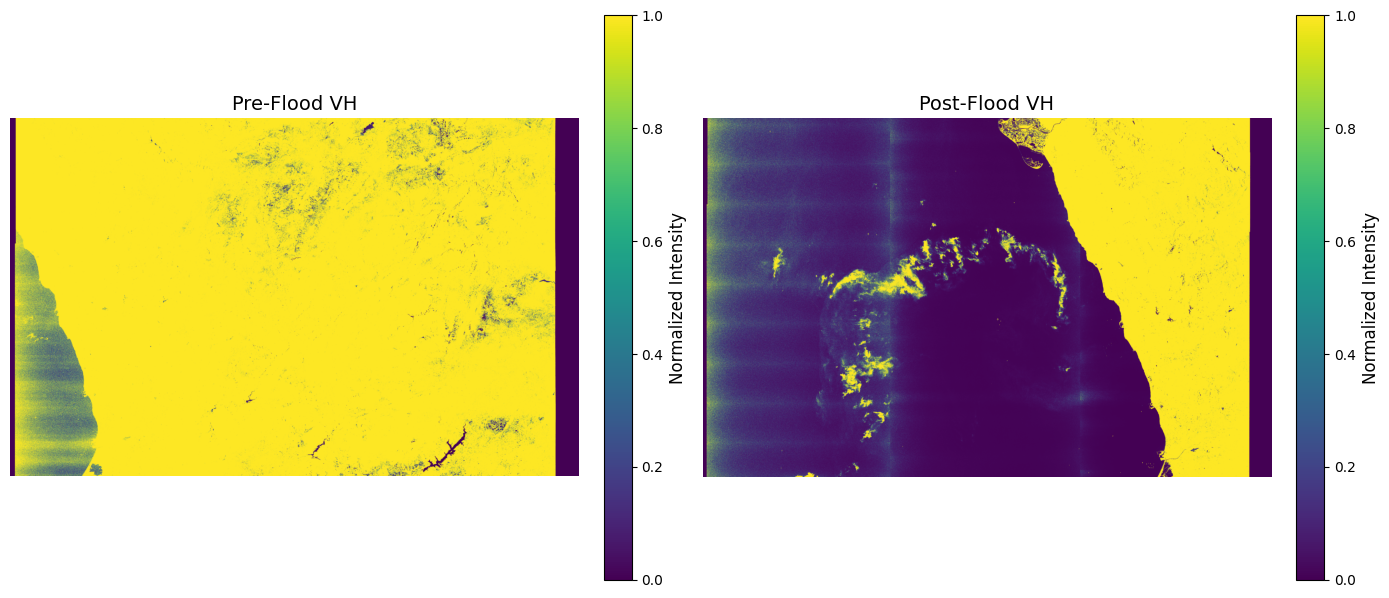

In [ ]:
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt

# Load SAR images with resampling to reduce size
def load_raster(file_path, scale_factor=0.3):
    with rasterio.open(file_path) as src:
        new_width = int(src.width * scale_factor)
        new_height = int(src.height * scale_factor)

        image = src.read(
            1,
            out_shape=(new_height, new_width),
            resampling=Resampling.bilinear
        ).astype(np.float32)  # Convert to float32 for processing

        profile = src.profile
    return image, profile

# Robust normalization (ignoring extreme values)
def robust_normalize(array, lower_percentile=2, upper_percentile=98):
    min_val = np.percentile(array, lower_percentile)
    max_val = np.percentile(array, upper_percentile)
    return np.clip((array - min_val) / (max_val - min_val + 1e-10), 0, 1)

# Convert dB to linear scale
def convert_to_linear(array):
   return 10 ** (np.clip(array, -50, 50) / 10) # Converts dB values to linear scale

# File paths (update if needed)
pre_flood_vh_path = "/content/drive/MyDrive/SAR/PRE FLOOD/S1A_IW_GRDH_1SDV_20240919T061016_20240919T061041_055730_06CE99_48B3.SAFE/measurement/s1a-iw-grd-vh-20240919t061016-20240919t061041-055730-06ce99-002.tiff"
post_flood_vh_path = "/content/drive/MyDrive/SAR/POST FLOOD/S1A_IW_GRDH_1SDV_20241101T060207_20241101T060232_056357_06E766_FEB3.SAFE/measurement/s1a-iw-grd-vh-20241101t060207-20241101t060232-056357-06e766-002.tiff"

# Load SAR images (Resampled)
pre_flood_vh, profile = load_raster(pre_flood_vh_path, scale_factor=0.3)
post_flood_vh, _ = load_raster(post_flood_vh_path, scale_factor=0.3)

# Print Min-Max values
print("Pre-Flood VH Min:", np.min(pre_flood_vh), "Max:", np.max(pre_flood_vh))
print("Post-Flood VH Min:", np.min(post_flood_vh), "Max:", np.max(post_flood_vh))

# Convert from dB to Linear Scale
pre_flood_vh = convert_to_linear(pre_flood_vh)
post_flood_vh = convert_to_linear(post_flood_vh)

# Normalize images for visualization
pre_flood_vh_norm = robust_normalize(pre_flood_vh)
post_flood_vh_norm = robust_normalize(post_flood_vh)

# Plot the SAR VH before and after the flood
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pre-Flood Image
im1 = axes[0].imshow(pre_flood_vh_norm, cmap='viridis')
axes[0].set_title("Pre-Flood VH", fontsize=14)
axes[0].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label('Normalized Intensity', fontsize=12)

# Post-Flood Image
im2 = axes[1].imshow(post_flood_vh_norm, cmap='viridis')
axes[1].set_title("Post-Flood VH", fontsize=14)
axes[1].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label('Normalized Intensity', fontsize=12)

# Adjust layout and show the figure
plt.tight_layout()
plt.show()


**Interpretation from the image**

The image shows side-by-side visualizations of SAR VH polarization data before and after a flood event, with normalized intensity values mapped using the `viridis` colormap.

- **Pre-Flood VH :**
  The pre-flood image shows high intensity values (yellow areas) spread uniformly across most of the region, indicating that the surface is largely dry or has consistent backscatter, possibly from vegetation or built-up areas. Darker regions (purple areas) indicate lower backscatter, possibly water bodies or smoother surfaces.

- **Post-Flood VH:**  
  The post-flood image reveals a significant change, with large portions of the area transitioning to darker regions (purple), especially in the central and lower areas. This drop in backscatter is indicative of increased water presence, as water absorbs the radar signal, reducing the returned intensity. The brighter regions along the edges suggest higher backscatter, possibly from built-up areas or remaining dry land.

**Key Observation:**  
The prominent darkening in the post-flood image, particularly in the central and low-lying areas, suggests the presence of floodwater, while the high-intensity regions remain relatively unaffected. The contrast between the two images highlights the extent of flooding in the region.

Speckle Filtering

This code applies the Lee speckle filter to reduce noise (speckle) in SAR images, which is common in radar data. The function normalizes the image to prevent overflow, computes the local mean and variance using a uniform filter over a specified window size (default 3x3), and estimates the overall variance of the image. The filter then applies a weighted combination of the mean and original pixel values based on the local and overall variance to suppress noise while preserving edges and fine details. The filtered image is converted back to an 8-bit format and any NaN values are replaced with zeros. This process is applied separately to the pre- and post-flood VV and VH polarization images to enhance image quality and facilitate more accurate analysis.

In [ ]:
import numpy as np

def clean_image(image):
    image = np.nan_to_num(image, nan=0.0, posinf=np.max(image[np.isfinite(image)]), neginf=np.min(image[np.isfinite(image)]))
    return image

# Apply cleaning
pre_flood_vv = clean_image(pre_flood_vv)
post_flood_vv = clean_image(post_flood_vv)
pre_flood_vh = clean_image(pre_flood_vh)
post_flood_vh = clean_image(post_flood_vh)


In [ ]:
def normalize_image(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-6)  # Avoid division by zero

# Apply normalization
pre_flood_vv = normalize_image(pre_flood_vv)
post_flood_vv = normalize_image(post_flood_vv)
pre_flood_vh = normalize_image(pre_flood_vh)
post_flood_vh = normalize_image(post_flood_vh)

# Check new min/max
print("Pre-flood VV min/max:", np.min(pre_flood_vv), np.max(pre_flood_vv))
print("Post-flood VV min/max:", np.min(post_flood_vv), np.max(post_flood_vv))
print("Pre-flood VH min/max:", np.min(pre_flood_vh), np.max(pre_flood_vh))
print("Post-flood VH min/max:", np.min(post_flood_vh), np.max(post_flood_vh))


Pre-flood VV min/max: 0.0 1.0
Post-flood VV min/max: 0.0 1.0
Pre-flood VH min/max: 0.0 1.0
Post-flood VH min/max: 0.0 1.0


In [ ]:
import numpy as np
from scipy.ndimage import uniform_filter

def lee_filter(image, window_size=3):
    """Apply Lee speckle filter to SAR image."""
    image = image.astype(np.float32)  # Convert to float32 to avoid overflow

    max_val = np.max(image)
    if max_val <= 0 or np.isnan(max_val):  # Prevent division by zero
        print("Warning: Max value is zero or NaN, returning original image.")
        return image.astype(np.uint8)

    image /= (max_val + 1e-6)  # Normalize safely

    mean = uniform_filter(image, window_size)
    mean_sqr = uniform_filter(image**2, window_size)
    variance_img = mean_sqr - mean**2

    if np.all(variance_img == 0):  # Check if entire variance is zero
        print("Warning: Image has uniform values, returning mean image.")
        return (mean * 255).astype(np.uint8)

    overall_variance = np.var(image)
    if overall_variance <= 0 or np.isnan(overall_variance):  # Prevent NaN issues
        print("Warning: Overall variance is zero or NaN, returning mean image.")
        return (mean * 255).astype(np.uint8)

    weight = variance_img / (variance_img + overall_variance + 1e-6)  # Avoid division by zero
    filtered_image = mean + weight * (image - mean)

    filtered_image = np.nan_to_num(filtered_image)  # Replace NaNs with 0
    return (filtered_image * 255).astype(np.uint8)  # Convert back to 8-bit image

# Apply Lee Filter
pre_flood_vv_filtered = lee_filter(pre_flood_vv)
post_flood_vv_filtered = lee_filter(post_flood_vv)
pre_flood_vh_filtered = lee_filter(pre_flood_vh)
post_flood_vh_filtered = lee_filter(post_flood_vh)


NDPI (Normalized Difference Polarization Index) is a ratio-based index used to detect changes in land cover or flooding by comparing VV (vertical-vertical) and VH (vertical-horizontal) polarization channels in SAR (Synthetic Aperture Radar) data.

NDPI=
VV+VH/
VV−VH

NDPI values range from -1 to 1
​


The code loads SAR images (VV and VH) for pre- and post-flood conditions from TIFF files, downsamples them to reduce memory usage, and computes NDPI for both time periods. It normalizes the NDPI values to a 0-1 range, converts them to 8-bit format for visualization, and then plots the NDPI maps before and after the flood using a blue color map. This allows for easy comparison of changes caused by the flood.

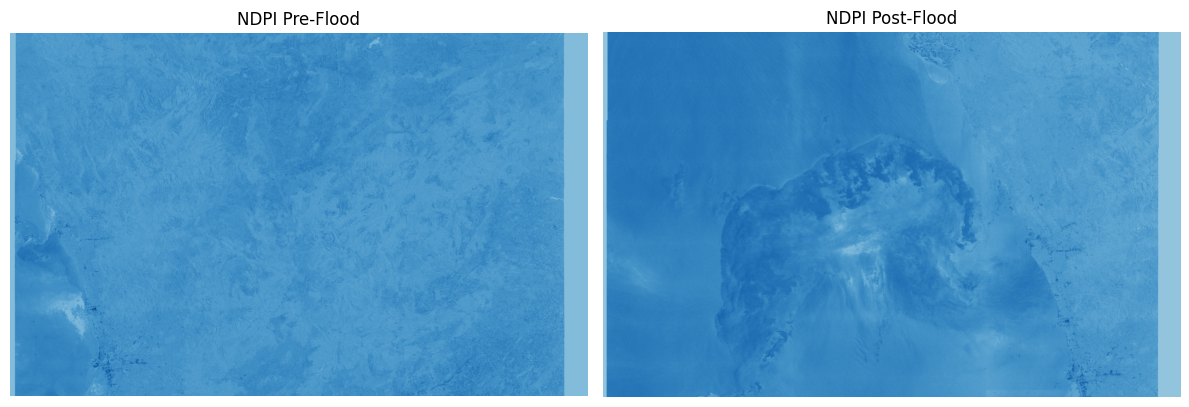

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling


# Compute NDPI (Normalized Difference Polarization Index)
def compute_ndpi(vv, vh):
    return (vv - vh) / (vv + vh + 1e-10)  # Avoid division by zero


# Load raster with optimized downsampling
def load_raster(file_path, downscale_factor=4):
    with rasterio.open(file_path) as src:
        # Downsample to reduce memory usage
        data = src.read(
            1,
            out_shape=(src.height // downscale_factor, src.width // downscale_factor),
            resampling=Resampling.average,
        ).astype(np.float32)
        return data, src.meta


# File paths to SAR TIFFs
pre_flood_vv_path = "/content/drive/MyDrive/SAR/PRE FLOOD/S1A_IW_GRDH_1SDV_20240919T061016_20240919T061041_055730_06CE99_48B3.SAFE/measurement/s1a-iw-grd-vv-20240919t061016-20240919t061041-055730-06ce99-001.tiff"
post_flood_vv_path = "/content/drive/MyDrive/SAR/POST FLOOD/S1A_IW_GRDH_1SDV_20241101T060207_20241101T060232_056357_06E766_FEB3.SAFE/measurement/s1a-iw-grd-vv-20241101t060207-20241101t060232-056357-06e766-001.tiff"

pre_flood_vh_path = "/content/drive/MyDrive/SAR/PRE FLOOD/S1A_IW_GRDH_1SDV_20240919T061016_20240919T061041_055730_06CE99_48B3.SAFE/measurement/s1a-iw-grd-vh-20240919t061016-20240919t061041-055730-06ce99-002.tiff"
post_flood_vh_path = "/content/drive/MyDrive/SAR/POST FLOOD/S1A_IW_GRDH_1SDV_20241101T060207_20241101T060232_056357_06E766_FEB3.SAFE/measurement/s1a-iw-grd-vh-20241101t060207-20241101t060232-056357-06e766-002.tiff"

# Load and downscale raster data
try:
    pre_flood_vv, meta = load_raster(pre_flood_vv_path)
    pre_flood_vh, _ = load_raster(pre_flood_vh_path)
    post_flood_vv, _ = load_raster(post_flood_vv_path)
    post_flood_vh, _ = load_raster(post_flood_vh_path)
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# Compute NDPI for pre- and post-flood
ndpi_pre = compute_ndpi(pre_flood_vv, pre_flood_vh)
ndpi_post = compute_ndpi(post_flood_vv, post_flood_vh)

# Normalize NDPI for visualization (0 to 1)
ndpi_pre = np.clip((ndpi_pre - np.min(ndpi_pre)) / (np.max(ndpi_pre) - np.min(ndpi_pre) + 1e-10), 0, 1)
ndpi_post = np.clip((ndpi_post - np.min(ndpi_post)) / (np.max(ndpi_post) - np.min(ndpi_post) + 1e-10), 0, 1)

# Convert NDPI to 8-bit for visualization
ndpi_pre_8bit = (ndpi_pre * 255).astype(np.uint8)
ndpi_post_8bit = (ndpi_post * 255).astype(np.uint8)

# Plot NDPI before and after flood
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(ndpi_pre_8bit, cmap="Blues")
axes[0].set_title("NDPI Pre-Flood")
axes[0].axis("off")

axes[1].imshow(ndpi_post_8bit, cmap="Blues")
axes[1].set_title("NDPI Post-Flood")
axes[1].axis("off")

plt.tight_layout()
plt.show()


**Interpretation of the NDPI Image**  
The image shows NDPI (Normalized Difference Polarization Index) maps for **pre-flood (left)** and **post-flood (right)** conditions.

- **Pre-Flood Image:**  
  - The pre-flood image has a relatively uniform texture, indicating that most of the area had consistent land cover before the flood.  
  - There are minor variations in polarization, suggesting different vegetation types and surface conditions.  

- **Post-Flood Image:**  
  - The post-flood image shows a distinct dark region in the center, indicating a large flooded area where the water has absorbed most of the radar signal, reducing the backscatter.  
  - Surrounding areas also show slight differences, implying changes in moisture content or surface roughness due to the flood.  

Key Insight:
The darker regions in the post-flood image highlight areas where water has accumulated, while the brighter regions correspond to non-flooded or less-affected areas. The NDPI index effectively visualizes the extent of flooding by highlighting polarization changes between VV and VH channels.

This code calculates and compares the NDPI (Normalized Difference Polarization Index) for pre-flood and post-flood SAR images in chunks to handle large datasets efficiently. It reads VV and VH polarization data from TIFF files of pre-flood and post-flood images, processes them in 1024x1024 chunks, computes the NDPI for each chunk, and assembles the results into full NDPI images.

 The resulting NDPI values are visualized using histograms that compare the pixel intensity distributions before and after the flood, highlighting polarization changes caused by flooding.










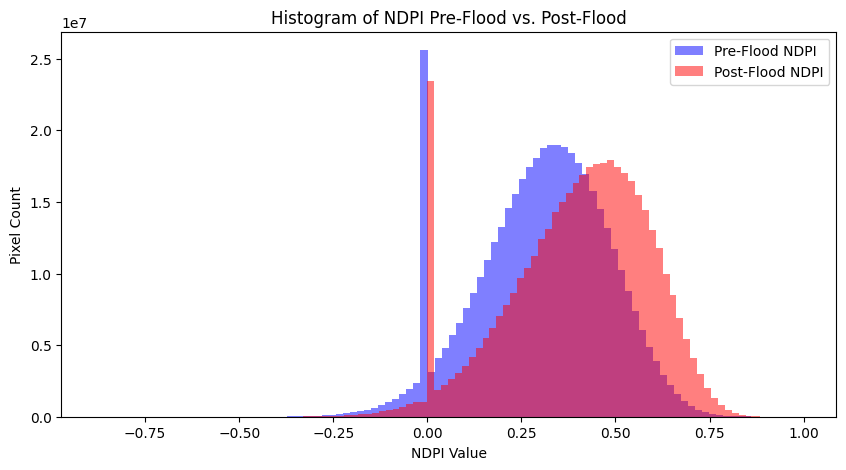

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window

def compute_ndpi(vv, vh, eps=1e-6):
    """Compute NDPI index while avoiding division by zero."""
    return (vv - vh) / np.maximum(vv + vh, eps)

def load_raster_chunk(file_path, window):
    """Loads a chunk of raster data with the given window."""
    with rasterio.open(file_path) as src:
        # Ensure window is within valid bounds
        window = window.intersection(Window(0, 0, src.width, src.height))
        data = src.read(1, window=window).astype(np.float32)
        return data

# Define file paths
pre_flood_vv_path = "/content/drive/MyDrive/SAR/PRE FLOOD/S1A_IW_GRDH_1SDV_20240919T061016_20240919T061041_055730_06CE99_48B3.SAFE/measurement/s1a-iw-grd-vv-20240919t061016-20240919t061041-055730-06ce99-001.tiff"
post_flood_vv_path = "/content/drive/MyDrive/SAR/POST FLOOD/S1A_IW_GRDH_1SDV_20241101T060207_20241101T060232_056357_06E766_FEB3.SAFE/measurement/s1a-iw-grd-vv-20241101t060207-20241101t060232-056357-06e766-001.tiff"

pre_flood_vh_path = "/content/drive/MyDrive/SAR/PRE FLOOD/S1A_IW_GRDH_1SDV_20240919T061016_20240919T061041_055730_06CE99_48B3.SAFE/measurement/s1a-iw-grd-vh-20240919t061016-20240919t061041-055730-06ce99-002.tiff"
post_flood_vh_path = "/content/drive/MyDrive/SAR/POST FLOOD/S1A_IW_GRDH_1SDV_20241101T060207_20241101T060232_056357_06E766_FEB3.SAFE/measurement/s1a-iw-grd-vh-20241101t060207-20241101t060232-056357-06e766-002.tiff"

# Get image dimensions
with rasterio.open(pre_flood_vv_path) as src:
    width, height = src.width, src.height

# Chunk processing
chunk_size = 1024
ndpi_pre = np.zeros((height, width), dtype=np.float32)
ndpi_post = np.zeros((height, width), dtype=np.float32)

for y in range(0, height, chunk_size):
    for x in range(0, width, chunk_size):
        win_width = min(chunk_size, width - x)
        win_height = min(chunk_size, height - y)
        window = Window(x, y, win_width, win_height)

        # Load raster chunks
        pre_vv = load_raster_chunk(pre_flood_vv_path, window)
        pre_vh = load_raster_chunk(pre_flood_vh_path, window)
        post_vv = load_raster_chunk(post_flood_vv_path, window)
        post_vh = load_raster_chunk(post_flood_vh_path, window)

        # Ensure shape consistency
        min_h, min_w = min(pre_vv.shape[0], pre_vh.shape[0], post_vv.shape[0], post_vh.shape[0]), \
                       min(pre_vv.shape[1], pre_vh.shape[1], post_vv.shape[1], post_vh.shape[1])

        pre_vv, pre_vh = pre_vv[:min_h, :min_w], pre_vh[:min_h, :min_w]
        post_vv, post_vh = post_vv[:min_h, :min_w], post_vh[:min_h, :min_w]

        # Compute NDPI
        ndpi_pre[y:y+min_h, x:x+min_w] = compute_ndpi(pre_vv, pre_vh)
        ndpi_post[y:y+min_h, x:x+min_w] = compute_ndpi(post_vv, post_vh)

        # Free memory
        del pre_vv, pre_vh, post_vv, post_vh

# Convert NaNs to zeros to avoid issues in visualization
ndpi_pre = np.nan_to_num(ndpi_pre)
ndpi_post = np.nan_to_num(ndpi_post)

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(ndpi_pre.flatten(), bins=100, alpha=0.5, color='blue', label='Pre-Flood NDPI')
plt.hist(ndpi_post.flatten(), bins=100, alpha=0.5, color='red', label='Post-Flood NDPI')
plt.xlabel("NDPI Value")
plt.ylabel("Pixel Count")
plt.legend()
plt.title("Histogram of NDPI Pre-Flood vs. Post-Flood")
plt.show()


**Histogram Interpretation of NDPI Pre-Flood vs. Post-Flood**

1. **Distribution Shift:**  
   - The histogram shows the pixel count distribution of NDPI values before (blue) and after (red) the flood.
   - The post-flood distribution (red) is shifted slightly to the right compared to the pre-flood distribution (blue), indicating a higher NDPI value post-flood, suggesting a change in surface reflectivity or structure due to flooding.

2. **Increased Polarization Differences:**  
   - Higher NDPI values after the flood indicate increased polarization differences, which often suggests surface changes, such as water inundation, vegetation loss, or soil saturation.

3. **Spike at Zero:**  
   - A noticeable spike around zero in both histograms suggests that many areas had minimal VV and VH differences, likely representing homogeneous surfaces such as water bodies or flat areas.

4. **Wider Post-Flood Distribution:**  
   - The post-flood histogram has a broader distribution, indicating increased variability in NDPI values, reflecting diverse surface changes caused by flooding.

5. **Pixel Count Comparison:**  
   - The overall pixel count is similar between pre- and post-flood images, confirming that the same area was analyzed in both cases.

**Conclusion:**  
The post-flood NDPI shows an increase in polarization differences, indicating surface alterations likely caused by flooding. The broader and shifted distribution suggests significant changes in the backscatter properties of the affected area.

The code performs flood detection by comparing pre- and post-flood SAR data (VV, VH, and NDPI) from Sentinel-1. It first crops all images to the same dimensions to handle mismatched sizes. Then, it computes the difference between post-flood and pre-flood data for VV, VH, and NDPI. NaN and zero values are handled to prevent errors, and NDPI differences are normalized. Flooded areas are identified using thresholds set at the 85th percentile for VV, VH, and NDPI differences, generating a binary flood mask. Finally, the code visualizes the VV, VH, and NDPI difference maps along with the detected flooded areas in a 2x2 grid of plots.

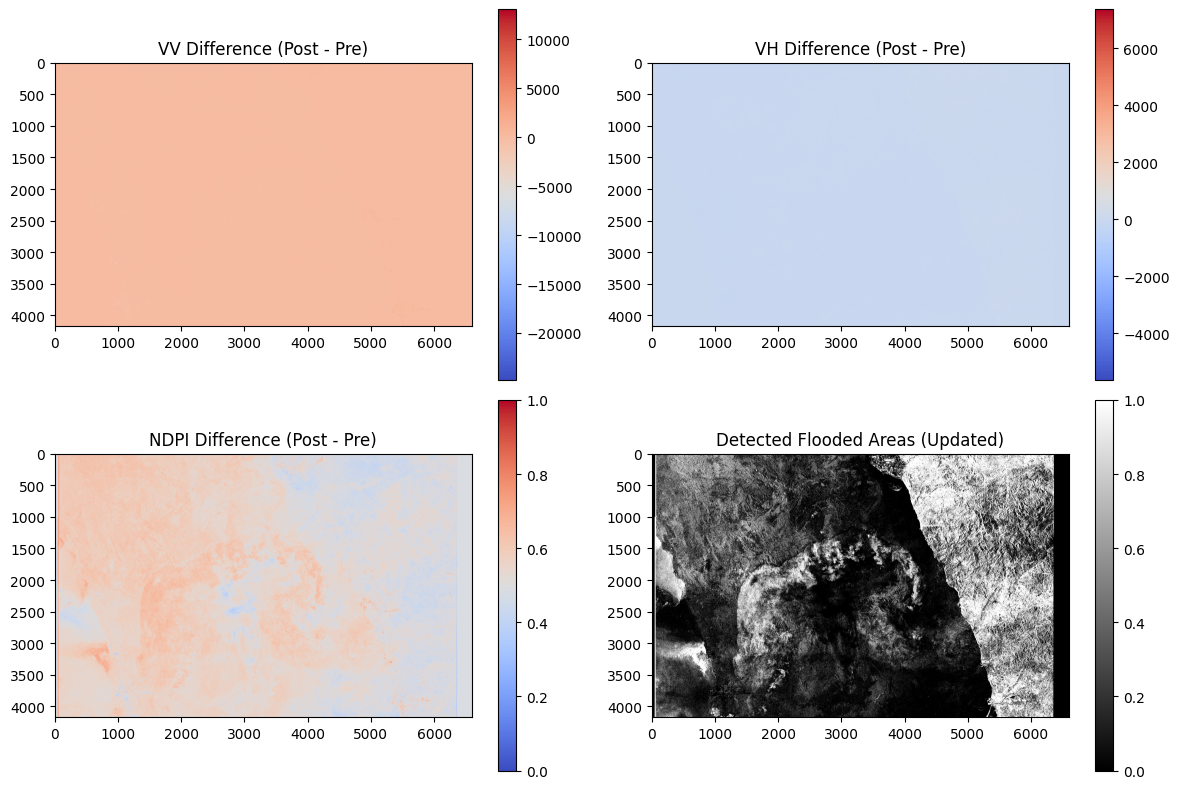

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# --- 🟢 Resize or Crop to Match Dimensions ---
# Crop to the minimum size to fix the mismatch
min_rows = min(pre_flood_vv.shape[0], post_flood_vv.shape[0])
min_cols = min(pre_flood_vv.shape[1], post_flood_vv.shape[1])

# Crop arrays to the same size
pre_flood_vv = pre_flood_vv[:min_rows, :min_cols]
post_flood_vv = post_flood_vv[:min_rows, :min_cols]
pre_flood_vh = pre_flood_vh[:min_rows, :min_cols]
post_flood_vh = post_flood_vh[:min_rows, :min_cols]
ndpi_pre = ndpi_pre[:min_rows, :min_cols]
ndpi_post = ndpi_post[:min_rows, :min_cols]

# --- 🟢 Compute Change Detection ---
vv_difference = post_flood_vv - pre_flood_vv
vh_difference = post_flood_vh - pre_flood_vh
ndpi_difference = ndpi_post - ndpi_pre

# --- 🟢 Handle NaNs and Zero Values ---
ndpi_pre[ndpi_pre == 0] = 1e-6  # Avoid division by zero
ndpi_difference = np.nan_to_num(ndpi_difference, nan=0.0, posinf=1.0, neginf=-1.0)

# --- 🟢 Normalize NDPI Difference ---
ndpi_diff_min = np.min(ndpi_difference)
ndpi_diff_max = np.max(ndpi_difference)

if ndpi_diff_max - ndpi_diff_min > 0:
    ndpi_difference = (ndpi_difference - ndpi_diff_min) / (ndpi_diff_max - ndpi_diff_min)
else:
    ndpi_difference = np.zeros_like(ndpi_difference)

# --- 🟢 Define Flood Detection Thresholds ---
vv_flood_threshold = np.percentile(vv_difference, 85)  # Adjusted threshold for accuracy
vh_flood_threshold = np.percentile(vh_difference, 85)
ndpi_flood_threshold = np.percentile(ndpi_difference, 85)

# --- 🟢 Detect Flooded Areas ---
flood_mask = (
    (vv_difference > vv_flood_threshold) |
    (vh_difference > vh_flood_threshold) |
    (ndpi_difference > ndpi_flood_threshold)
)

# --- 🟢 Plot Updated Maps ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# VV Difference Map
im1 = axes[0, 0].imshow(vv_difference, cmap='coolwarm', vmin=np.min(vv_difference), vmax=np.max(vv_difference))
axes[0, 0].set_title("VV Difference (Post - Pre)")
plt.colorbar(im1, ax=axes[0, 0])

# VH Difference Map
im2 = axes[0, 1].imshow(vh_difference, cmap='coolwarm', vmin=np.min(vh_difference), vmax=np.max(vh_difference))
axes[0, 1].set_title("VH Difference (Post - Pre)")
plt.colorbar(im2, ax=axes[0, 1])

# NDPI Difference Map
im3 = axes[1, 0].imshow(ndpi_difference, cmap='coolwarm', vmin=0, vmax=1)
axes[1, 0].set_title("NDPI Difference (Post - Pre)")
plt.colorbar(im3, ax=axes[1, 0])

# Flood Mask Visualization
im4 = axes[1, 1].imshow(flood_mask.astype(float), cmap='gray')
axes[1, 1].set_title("Detected Flooded Areas (Updated)")
plt.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()


**Interpretation from the image**

**VV Difference (Post - Pre)**

Summary:

Shows change in VV polarization post-flood.

🟥 Red Areas: Increased backscatter due to double-bounce effects (water near structures).

🟦 Blue Areas: Decreased backscatter, indicating smoother surfaces, likely flooded areas.

Significance:

Helps detect water-logged areas and changes in surface properties.

**VH Difference (Post - Pre)**

Summary:

Highlights VH polarization differences sensitive to surface roughness and vegetation.

🟦 Blue Areas: Reduced backscatter suggests smoother, potentially flooded surfaces.

🟥 Red Areas: Minor increase in roughness in some areas.

Significance:

VH helps identify submerged or damaged vegetation after floods.

**NDPI Difference (Post - Pre)**

Summary:

NDPI change map reflecting polarization differences.

🟦 Blue Areas: Decreased NDPI suggests water presence.

🟥 Red Areas: Increased NDPI indicates rougher surfaces or structural changes.

Significance:

Confirms flooded regions and polarization changes post-flood.

**Detected Flooded Areas**

Summary:

Flood mask highlighting affected areas.

⚫️ Black Areas: Non-flooded regions.

⚪️ White/Gray Areas: Detected flooded zones.


Significance:

Combines VV, VH, and NDPI for robust flood detection.

In [ ]:
# pre_flood_vv_path = "/content/drive/MyDrive/SAR/PRE FLOOD/S1A_IW_GRDH_1SDV_20240919T061016_20240919T061041_055730_06CE99_48B3.SAFE/measurement/s1a-iw-grd-vv-20240919t061016-20240919t061041-055730-06ce99-001.tiff"
# post_flood_vv_path = "/content/drive/MyDrive/SAR/POST FLOOD/S1A_IW_GRDH_1SDV_20241101T060207_20241101T060232_056357_06E766_FEB3.SAFE/measurement/s1a-iw-grd-vv-20241101t060207-20241101t060232-056357-06e766-001.tiff"

# pre_flood_vh_path = "/content/drive/MyDrive/SAR/PRE FLOOD/S1A_IW_GRDH_1SDV_20240919T061016_20240919T061041_055730_06CE99_48B3.SAFE/measurement/s1a-iw-grd-vh-20240919t061016-20240919t061041-055730-06ce99-002.tiff"
# post_flood_vh_path = "/content/drive/MyDrive/SAR/POST FLOOD/S1A_IW_GRDH_1SDV_20241101T060207_20241101T060232_056357_06E766_FEB3.SAFE/measurement/s1a-iw-grd-vh-20241101t060207-20241101t060232-056357-06e766-002.tiff"


**Training and Evaluating Machine Learning Models for Flood Prediction**

Input (Features)
The models use the following features as input:

VV Difference (Post - Pre) — Change in SAR VV backscatter before and after the flood.

VH Difference (Post - Pre) — Change in SAR VH backscatter before and after the flood.

NDPI Difference (Post - Pre) — Change in NDPI values before and after the flood.

 Output (Target/Label)
The models predict:

Flooded or Not Flooded Areas

Binary Classification:

1 — Flooded area

0 — Non-flooded area

Shape of Output:

y_train and y_test are binary arrays of shape (num_samples,), indicating whether the corresponding pixel/region is flooded.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# --- 🟢 Flatten Data for Model Input ---
# Flatten the arrays into 1D feature vectors
X = np.stack([vv_difference.flatten(), vh_difference.flatten(), ndpi_difference.flatten()], axis=1)
y = flood_mask.flatten().astype(np.uint8)

# --- 🟢 Remove No-Data Values ---
valid_mask = ~np.isnan(X).any(axis=1)
X = X[valid_mask]
y = y[valid_mask]

# --- 🟢 Split Data into Training and Test Sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [ ]:
X_train

array([[   0.        ,    0.        ,    0.4862138 ],
       [-188.        ,  -88.        ,    0.5082455 ],
       [ -33.        ,  -35.        ,    0.5852245 ],
       ...,
       [-184.        ,  -85.        ,    0.50296116],
       [ -17.        ,  -53.        ,    0.62819755],
       [ -35.        ,  -47.        ,    0.5827489 ]], dtype=float32)

In [ ]:
X_test

array([[-100.        ,  -44.        ,    0.4838448 ],
       [  82.        ,   36.        ,    0.51210785],
       [  -8.        ,  -15.        ,    0.5181301 ],
       ...,
       [ -70.        ,  -50.        ,    0.53009474],
       [  42.        ,   33.        ,    0.46886307],
       [-168.        , -117.        ,    0.58297133]], dtype=float32)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 20 features (can be adjusted based on data)
selector = SelectKBest(f_classif, k=20)
X_train_reduced = selector.fit_transform(X_train, y_train)
X_test_reduced = selector.transform(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=20 is greater than n_features=3. All the features will be returned.
  warnings.warn(


In [ ]:
X_train_reduced

array([[   0.        ,    0.        ,    0.4862138 ],
       [-188.        ,  -88.        ,    0.5082455 ],
       [ -33.        ,  -35.        ,    0.5852245 ],
       ...,
       [-184.        ,  -85.        ,    0.50296116],
       [ -17.        ,  -53.        ,    0.62819755],
       [ -35.        ,  -47.        ,    0.5827489 ]], dtype=float32)

In [ ]:
X_test_reduced

array([[-100.        ,  -44.        ,    0.4838448 ],
       [  82.        ,   36.        ,    0.51210785],
       [  -8.        ,  -15.        ,    0.5181301 ],
       ...,
       [ -70.        ,  -50.        ,    0.53009474],
       [  42.        ,   33.        ,    0.46886307],
       [-168.        , -117.        ,    0.58297133]], dtype=float32)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# --- 🟢 Train Logistic Regression ---
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train_reduced, y_train)

# --- 🟢 Predict on Test Set ---
y_pred_lr = lr_model.predict(X_test_reduced)

# --- 🟢 Evaluate Model ---
print("Logistic Regression Performance:\n")
print(classification_report(y_test, y_pred_lr))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")


Logistic Regression Performance:

              precision    recall  f1-score   support

           0       0.84      0.91      0.88   5575539
           1       0.78      0.64      0.70   2672621

    accuracy                           0.82   8248160
   macro avg       0.81      0.78      0.79   8248160
weighted avg       0.82      0.82      0.82   8248160

Accuracy: 82.48%


In [ ]:
y_pred_lr

array([0, 1, 0, ..., 0, 1, 0], dtype=uint8)

In [ ]:
from xgboost import XGBClassifier

# --- 🟢 Train XGBoost ---
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_reduced, y_train)

# --- 🟢 Predict on Test Set ---
y_pred_xgb = xgb_model.predict(X_test_reduced)

# --- 🟢 Evaluate Model ---
print("XGBoost Model Performance:\n")
print(classification_report(y_test, y_pred_xgb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")


XGBoost Model Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   5575539
           1       1.00      1.00      1.00   2672621

    accuracy                           1.00   8248160
   macro avg       1.00      1.00      1.00   8248160
weighted avg       1.00      1.00      1.00   8248160

Accuracy: 99.87%


In [ ]:
y_pred_xgb

array([0, 1, 0, ..., 0, 1, 0])